# Structural Analysis of the MUTAG Dataset

This notebook performs a structural analysis of the MUTAG dataset.

The MUTAG dataset consists of multiple small graphs representing molecular structures, where nodes correspond to atoms and edges represent chemical bonds.

Since the dataset contains many independent graphs rather than a single global structure, structural statistics are computed per graph and then aggregated across the dataset.

These diagnostics aim to identify potential structural bottlenecks and characterize information flow within graphs.

In [1]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import TUDataset
from torch_geometric.utils import to_networkx, degree
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.loader import DataLoader

from torch.utils.data import random_split

import networkx as nx

c:\Master\GAI\gnn-over-squashing-cora\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("../results/plots/mutag", exist_ok=True)
os.makedirs("../results/tables/mutag", exist_ok=True)

## Dataset

The experiments are conducted on the MUTAG dataset

In [3]:
dataset = TUDataset(root="../data", name="MUTAG")

print(len(dataset))
print(dataset.num_features)
print(dataset.num_classes)

188
7
2


## Models

In [4]:
sys.path.append(os.path.abspath(".."))

from src.models.graph_classification import GCN, GraphSAGE, GAT

from src.training.train import train_graph_classification
from src.training.evaluate import evaluate_graph_classification

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

himutagen_dim = 64
epochs = 200
lr = 0.001
weight_decay = 0.0005

layer_values = [2, 4, 6, 8]
seeds = [0, 1, 2, 3, 4]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}

num_graphs = len(dataset)
train_size = int(0.8 * num_graphs)
test_size = num_graphs - train_size

batch_size = 32

for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for num_layers in layer_values:

        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            split_generator = torch.Generator().manual_seed(seed)

            train_dataset, test_dataset = random_split(
                dataset,
                [train_size, test_size],
                generator=split_generator
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True,
                generator=torch.Generator().manual_seed(seed)
            )

            test_loader = DataLoader(
                test_dataset,
                batch_size=batch_size,
                shuffle=False
            )

            model = Model(in_dim, himutagen_dim, num_classes, num_layers).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            history = train_graph_classification(
                model,
                train_loader,
                optimizer,
                epochs=epochs,
                device=device
            )

            elapsed = time.time() - start

            acc = evaluate_graph_classification(
                model,
                test_loader,
                device=device
            )

            acc_runs.append(acc)
            time_runs.append(elapsed)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

        # plot(history)

Running on cuda

Running experiments for GCN


100%|██████████| 200/200 [00:08<00:00, 22.67it/s]


Layers: 2 | Accuracy: 0.7000 ± 0.0459


100%|██████████| 200/200 [00:13<00:00, 14.89it/s]


Layers: 4 | Accuracy: 0.7158 ± 0.0562


...

Layers: 4 | Accuracy: 0.6684 ± 0.0542


100%|██████████| 200/200 [01:03<00:00,  3.16it/s]


Layers: 6 | Accuracy: 0.6632 ± 0.0609


100%|██████████| 200/200 [00:37<00:00,  5.34it/s]

Layers: 8 | Accuracy: 0.6895 ± 0.0714


In [ ]:
def plot(history):
    epochs = range(len(history["train_loss"]))

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss plot ---
    axs[0].plot(epochs, history["train_loss"])
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    # --- Accuracy plot ---
    axs[1].plot(epochs, history["train_acc"])
    axs[1].set_title("Training Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()


In [6]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

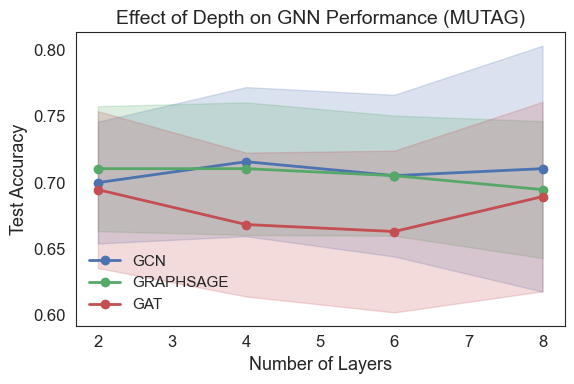

In [7]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    layers = data["layers"]
    mean = np.array(data["acc_mean"])
    std = np.array(data["acc_std"])

    plt.plot(
        layers,
        mean,
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

    # banda de variabilidad (mean ± std)
    plt.fill_between(
        layers,
        mean - std,
        mean + std,
        color=colors[model],
        alpha=0.2
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (MUTAG)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/mutag/accuracy_vs_layers.png", dpi=300)

plt.show()

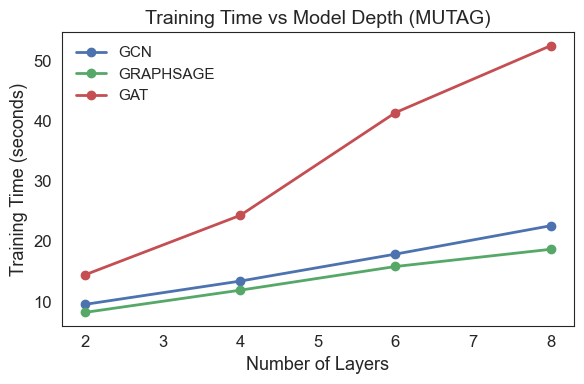

In [8]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth (MUTAG)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/mutag/time_vs_layers.png", dpi=300)

plt.show()

In [11]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy_mean": results[model]["acc_mean"][i],
            "accuracy_std": results[model]["acc_std"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../results/tables/mutag/gnn_layer_experiments.csv", index=False)

In [12]:
with open("../results/tables/mutag/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [5]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

print("Average nodes per graph:", np.mean(num_nodes))
print("Minimum nodes per graph:", np.min(num_nodes))
print("Maximun nodes per graph:", np.max(num_nodes))
print("Average edges per graph:", np.mean(num_edges))
print("Minimum edges per graph:", np.min(num_edges))
print("Maximum edges per graph:", np.max(num_edges))

Average nodes per graph: 17.930851063829788
Minimum nodes per graph: 10
Maximun nodes per graph: 28
Average edges per graph: 39.58510638297872
Minimum edges per graph: 20
Maximum edges per graph: 66


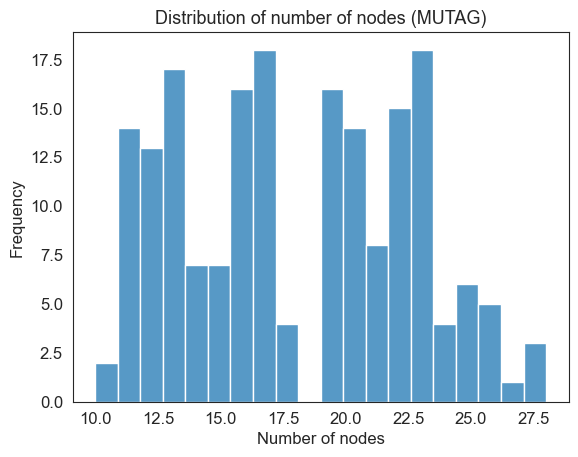

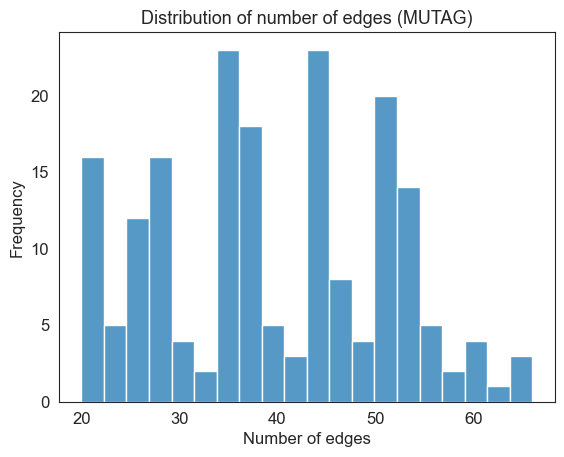

In [6]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

plt.figure()
sns.histplot(num_nodes, bins=20, kde=False)
plt.title("Distribution of number of nodes (MUTAG)")
plt.xlabel("Number of nodes")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/mutag/distribution_nodes.png",
    dpi=300
)
plt.show()

plt.figure()
sns.histplot(num_edges, bins=20, kde=False)
plt.title("Distribution of number of edges (MUTAG)")
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/mutag/distribution_edges.png",
    dpi=300
)
plt.show()

In [7]:
nx_graphs = []

for data in dataset:
    G = to_networkx(data, to_undirected=True)
    nx_graphs.append(G)

print("Converted graphs:", len(nx_graphs))

Converted graphs: 188


In [8]:
betweenness_values = []

for G in nx_graphs:
    if G.number_of_edges() == 0:
        continue
        
    edge_bet = nx.edge_betweenness_centrality(G)
    betweenness_values.extend(edge_bet.values())

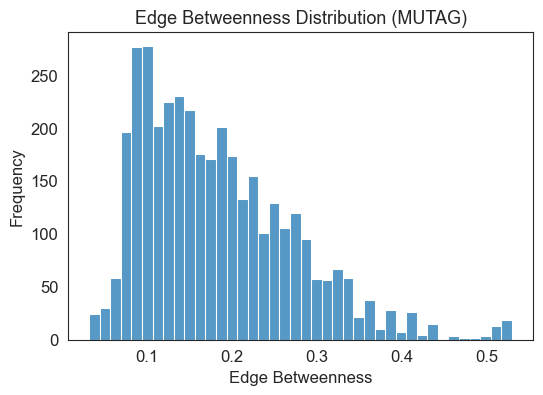

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(betweenness_values, bins=40)

plt.xlabel("Edge Betweenness")
plt.ylabel("Frequency")
plt.title("Edge Betweenness Distribution (MUTAG)")
plt.savefig(
    "../results/plots/mutag/edge_betweenness.png",
    dpi=300
)

plt.show()

The edge betweenness distribution is highly skewed, with most edges exhibiting low centrality and a small subset acting as structural bridges. This suggests the presence of bottlenecks, where information flow is forced through a limited number of critical edges, potentially leading to over-squashing in deep GNNs.

In [10]:
top_values = sorted(betweenness_values)[-50:]
top_values = np.sort(top_values)

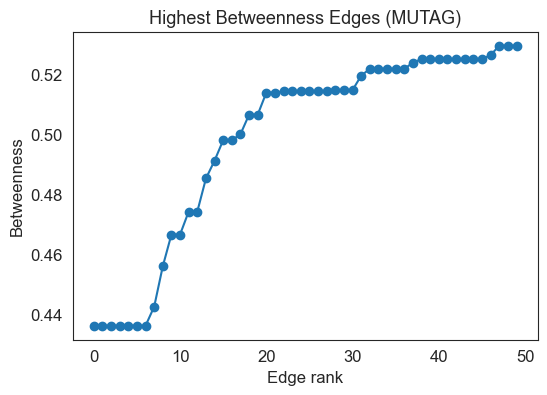

In [11]:
plt.figure(figsize=(6,4))

plt.plot(top_values, marker='o')

plt.xlabel("Edge rank")
plt.ylabel("Betweenness")
plt.title("Highest Betweenness Edges (MUTAG)")
plt.savefig(
    "../results/plots/mutag/highest_betweenness_edges.png",
    dpi=300
)
plt.show()

The top-ranked edges exhibit consistently high betweenness values, indicating the presence of multiple structural bottlenecks. These edges act as critical bridges for information flow, suggesting that message passing in deep GNNs may be constrained by limited communication capacity, potentially leading to over-squashing.

In [12]:
"""
Computes per-graph edge betweenness statistics.

Returns:
    dict with:
        - max: list of max betweenness per graph
        - mean: list of mean betweenness per graph
        - p95: list of 95th percentile per graph
"""

max_vals = []
mean_vals = []
p95_vals = []

for data in dataset:

    # convertir a NetworkX
    edge_index = data.edge_index.cpu().numpy()
    G = nx.Graph()
    G.add_edges_from(edge_index.T)

    # betweenness de aristas
    eb = nx.edge_betweenness_centrality(G)

    values = np.array(list(eb.values()))

    if len(values) == 0:
        continue

    max_vals.append(values.max())
    mean_vals.append(values.mean())
    p95_vals.append(np.percentile(values, 95))

stats = {
        "max": max_vals,
        "mean": mean_vals,
        "p95": p95_vals
    }

print("Avg max:", np.mean(stats["max"]))
print("Avg p95:", np.mean(stats["p95"]))

Avg max: 0.3710941734316039
Avg p95: 0.33202609950955053


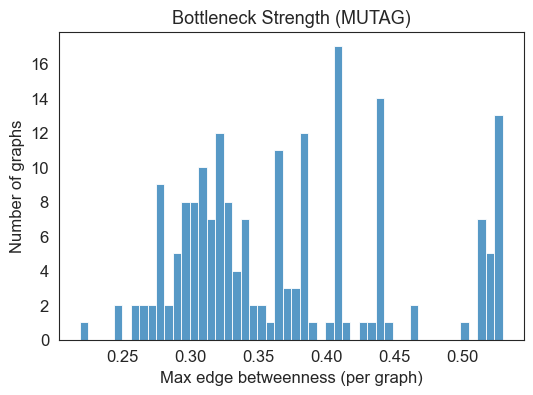

In [13]:
plt.figure(figsize=(6,4))

sns.histplot(stats["max"], bins=50)

plt.xlabel("Max edge betweenness (per graph)")
plt.ylabel("Number of graphs")
plt.title("Bottleneck Strength (MUTAG)")
plt.savefig(
    "../results/plots/mutag/bottleneck_strength.png",
    dpi=300
)
plt.show()

A significant portion of graphs exhibit high-betweenness edges, indicating that structural bottlenecks are widespread across the dataset.

In [14]:
def average_khop_growth(graphs, max_k=5):

    growth = []

    for k in range(1, max_k+1):

        sizes = []

        for G in graphs:

            if len(G.nodes()) == 0:
                continue

            node = list(G.nodes())[0]

            nodes = nx.single_source_shortest_path_length(G, node, cutoff=k)

            sizes.append(len(nodes))

        growth.append(np.mean(sizes))

    return growth

In [15]:
khop_growth = average_khop_growth(nx_graphs)

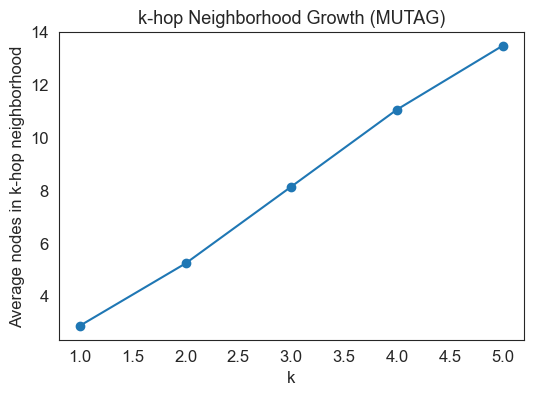

In [16]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), khop_growth, marker='o')

plt.xlabel("k")
plt.ylabel("Average nodes in k-hop neighborhood")
plt.title("k-hop Neighborhood Growth (MUTAG)")
plt.savefig(
    "../results/plots/mutag/average_nodes_in_khop.png",
    dpi=300
)
plt.show()

The k-hop neighborhood grows approximately linearly, indicating limited expansion of receptive fields. This suggests that deeper GNNs are required to capture long-range dependencies, although the moderate growth rate may mitigate severe over-squashing effects.